# AHN4 validation strip for v7 LiDAR profile

At a chosen time `T` in the rosbag, this notebook:

1. Looks up the bike's GPS position at that time.
2. Estimates the bike's heading from a short window of GPS displacement.
3. Builds a sample strip along that heading from `X_BACK` (default −5 m, behind)
   to `X_FRONT` (default +25 m, in front), spaced every `DX` (default 0.5 m).
4. Queries the official Dutch AHN4 DTM **once** with a single bbox covering the
   whole strip and samples elevation at every point.
5. Returns a `profile_ahn4` dict with the same `x`/`z`/`slope_deg`/`kappa`
   schema as the v7 profile, so the two can be overlaid directly.

The output is a "ground truth" forward profile against which the v7 LiDAR
profile can be validated.


In [3]:
from mcap.reader import make_reader
from mcap_ros2.decoder import DecoderFactory
import matplotlib.pyplot as plt
import numpy as np
from pyproj import Transformer
import requests
import rasterio
import io
import math

# ============================================================
# SETTINGS — edit these before running
# ============================================================

GPS_FILE_PATH      = r"D:\Rosbags\01 mei\14_20_00\rosbag\rosbag_0.mcap"
GPS_LAT_LON_TOPIC  = "/navsat_topic"           # set to None to list topics

# === The single timestamp to validate ===
# Unix epoch seconds. Set to None to fall back to FRAME_INDEX instead.
# Cell 3 prints the bag's time range so you know what TIME values are valid.
TIME               = 1777638090.508194
FRAME_INDEX        = None                       # used only when TIME is None

# === Strip geometry  (must match v7's ROI for direct overlay) ===
X_BACK             = -5.0                      # m behind the bike
X_FRONT            = 25.0                      # m in front
DX                 = 0.5                       # spacing along forward axis

# === Heading estimation ===
HEADING_WINDOW_S   = 1.0                       # ± seconds for GPS displacement


## 1. Read GPS from the bag

In [4]:
gps_coords = {"t": [], "lat": [], "lon": []}

print("Reading GPS bag:", GPS_FILE_PATH)

with open(GPS_FILE_PATH, "rb") as f:
    reader = make_reader(f, decoder_factories=[DecoderFactory()])

    if GPS_LAT_LON_TOPIC is None:
        print("\nGPS_LAT_LON_TOPIC is None. Available topics:")
        summary = reader.get_summary()
        for ch in summary.channels.values():
            n = summary.statistics.channel_message_counts.get(ch.id, "?")
            schema = summary.schemas.get(ch.schema_id, None)
            schema_name = schema.name if schema else "unknown"
            print(f"  {ch.topic}  —  {n} messages  [{schema_name}]")
        raise SystemExit("Set GPS_LAT_LON_TOPIC and re-run this cell.")

    for schema, channel, message, ros_msg in reader.iter_decoded_messages():
        if channel.topic == GPS_LAT_LON_TOPIC:
            gps_coords["t"].append(message.publish_time / 1e9)
            gps_coords["lat"].append(ros_msg.latitude)
            gps_coords["lon"].append(ros_msg.longitude)

times = np.array(gps_coords["t"])
lats  = np.array(gps_coords["lat"])
lons  = np.array(gps_coords["lon"])

if len(times) == 0:
    raise RuntimeError(f"No messages on topic '{GPS_LAT_LON_TOPIC}'. "
                       "Set GPS_LAT_LON_TOPIC = None to list available topics.")

print(f"  GPS messages   : {len(times)}")
print(f"  Bag time range : {times[0]:.2f}  →  {times[-1]:.2f}")
print(f"  Duration       : {times[-1] - times[0]:.1f} s "
      f"({(times[-1] - times[0])/60:.1f} min)")


Reading GPS bag: D:\Rosbags\01 mei\14_20_00\rosbag\rosbag_0.mcap
  GPS messages   : 2977
  Bag time range : 1777638002.97  →  1777638300.58
  Duration       : 297.6 s (5.0 min)


## 2. Convert to Dutch RD New (EPSG:28992)

In [5]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:28992", always_xy=True)
rd_xs, rd_ys = transformer.transform(lons, lats)
rd_xs = np.array(rd_xs)
rd_ys = np.array(rd_ys)

print(f"  RD X range : {rd_xs.min():.1f}  →  {rd_xs.max():.1f}")
print(f"  RD Y range : {rd_ys.min():.1f}  →  {rd_ys.max():.1f}")


  RD X range : 84406.5  →  84560.9
  RD Y range : 446899.8  →  447285.5


## 3. Pick the moment in time and estimate heading

Heading comes from the bike's GPS displacement over `±HEADING_WINDOW_S`
seconds — this is robust as long as the bike was moving at that moment.
If the bike was stationary, the cell raises an error: pick a different `TIME`.


In [6]:
# === pick the reference message ===
if TIME is None:
    ref_idx = max(0, min(FRAME_INDEX, len(times) - 1))
    print(f"Using FRAME_INDEX = {ref_idx}")
else:
    ref_idx = int(np.argmin(np.abs(times - TIME)))
    dt = abs(times[ref_idx] - TIME)
    print(f"Using TIME = {TIME}, closest GPS message Δt = {dt:.3f}s "
          f"(index {ref_idx})")

ref_t    = float(times[ref_idx])
ref_lat  = float(lats[ref_idx])
ref_lon  = float(lons[ref_idx])
ref_rd_x = float(rd_xs[ref_idx])
ref_rd_y = float(rd_ys[ref_idx])

# === heading from GPS displacement over a short window ===
mask = (times >= ref_t - HEADING_WINDOW_S) & (times <= ref_t + HEADING_WINDOW_S)
win_x = rd_xs[mask]
win_y = rd_ys[mask]

if len(win_x) < 3:
    raise RuntimeError(
        f"Only {len(win_x)} GPS samples in ±{HEADING_WINDOW_S}s window. "
        "Increase HEADING_WINDOW_S.")

hd_x = win_x[-1] - win_x[0]
hd_y = win_y[-1] - win_y[0]
hd_norm = math.hypot(hd_x, hd_y)

if hd_norm < 0.5:
    raise RuntimeError(
        f"Bike moved only {hd_norm*100:.1f} cm in window — "
        "stationary, heading undefined. Pick a different TIME.")

heading_x   = hd_x / hd_norm
heading_y   = hd_y / hd_norm
heading_deg = math.degrees(math.atan2(hd_y, hd_x))

print(f"  Reference position : ({ref_lat:.6f}, {ref_lon:.6f})")
print(f"  RD coordinates     : ({ref_rd_x:.2f}, {ref_rd_y:.2f})")
print(f"  Heading            : {heading_deg:.1f}°  "
      f"(displacement {hd_norm:.2f} m over ±{HEADING_WINDOW_S}s)")

# === sample points along the forward axis ===
x_samples = np.arange(X_BACK, X_FRONT + DX, DX)
sample_xs_rd = ref_rd_x + x_samples * heading_x
sample_ys_rd = ref_rd_y + x_samples * heading_y

print(f"  Strip from x={X_BACK}m to x={X_FRONT}m, {len(x_samples)} samples")


Using TIME = 1777638090.508194, closest GPS message Δt = 0.033s (index 875)
  Reference position : (52.008035, 4.360368)
  RD coordinates     : (84499.43, 447127.84)
  Heading            : -158.0°  (displacement 6.46 m over ±1.0s)
  Strip from x=-5.0m to x=25.0m, 61 samples


## 4. Query AHN4 DTM (one API call)

The whole strip fits in a small bounding box, so we issue **one** WCS request
covering it and sample every point from the returned GeoTIFF in memory. This
is much faster than per-point queries (no rate-limit risk, no `time.sleep`).


In [7]:
margin = 1.0    # m of padding around the strip
xmin = sample_xs_rd.min() - margin
xmax = sample_xs_rd.max() + margin
ymin = sample_ys_rd.min() - margin
ymax = sample_ys_rd.max() + margin

# AHN4 DTM resolution = 0.5 m
res = 0.5
gw  = int(math.ceil((xmax - xmin) / res)) + 1
gh  = int(math.ceil((ymax - ymin) / res)) + 1
print(f"Querying AHN4: bbox ({xmin:.1f}, {ymin:.1f}) → ({xmax:.1f}, {ymax:.1f})")
print(f"  Grid size : {gw} × {gh}  ({gw*gh} pixels)")

wcs_url = "https://service.pdok.nl/rws/ahn/wcs/v1_0"
params  = {
    "service":  "WCS",
    "version":  "1.0.0",
    "request":  "GetCoverage",
    "coverage": "dtm_05m",
    "crs":      "EPSG:28992",
    "bbox":     f"{xmin},{ymin},{xmax},{ymax}",
    "width":    gw,
    "height":   gh,
    "format":   "GEOTIFF",
}
resp = requests.get(wcs_url, params=params, timeout=30)
resp.raise_for_status()
print(f"  AHN4 returned {len(resp.content)} bytes")

# === sample elevation at every point along the strip ===
z_samples = np.full(len(x_samples), np.nan)

with rasterio.open(io.BytesIO(resp.content)) as src:
    no_data = src.nodata
    sampled = list(src.sample(zip(sample_xs_rd, sample_ys_rd)))
    for i, vals in enumerate(sampled):
        v = float(vals[0])
        if no_data is not None and v == no_data:
            continue
        if not np.isfinite(v):
            continue
        if -100 < v < 200:    # plausibility
            z_samples[i] = v

valid = ~np.isnan(z_samples)
print(f"  Valid elevations : {valid.sum()} / {len(z_samples)}")
if valid.any():
    print(f"  NAP range        : {np.nanmin(z_samples):.2f} → {np.nanmax(z_samples):.2f} m")


Querying AHN4: bbox (84475.2, 447117.5) → (84505.1, 447130.7)
  Grid size : 61 × 28  (1708 pixels)
  AHN4 returned 4122 bytes
  Valid elevations : 51 / 61
  NAP range        : 0.84 → 1.76 m


## 5. Build `profile_ahn4` dict

The dict mirrors the v7 profile schema (`x`, `z`, `slope_deg`, `kappa`) so it
can be overlaid directly. The `z` field is **shifted so z(0) = 0** at the bike's
position — same convention as the v7 LiDAR-frame profile.
The original NAP elevations are kept as `z_absolute` for reference.


In [8]:
# === interpolate over any NaN gaps before differentiating ===
if not valid.all():
    z_filled = np.interp(x_samples, x_samples[valid], z_samples[valid])
else:
    z_filled = z_samples.copy()

# === reference height at x = 0 (bike's current position) ===
ref_z_idx = int(np.argmin(np.abs(x_samples)))
ref_z_nap = float(z_filled[ref_z_idx])
z_relative = z_filled - ref_z_nap

# === slope and curvature using the same formula as v7 ===
dzdx       = np.gradient(z_relative, DX)
slope_deg  = np.degrees(np.arctan(dzdx))
d2zdx2     = np.gradient(dzdx, DX)
kappa      = d2zdx2 / (1.0 + dzdx ** 2) ** 1.5

profile_ahn4 = {
    "x":            x_samples,
    "z":            z_relative,         # bike-local frame (z=0 at bike)
    "z_absolute":   z_filled,           # raw NAP elevations
    "slope_deg":    slope_deg,
    "kappa":        kappa,
    "method":       "AHN4 DTM",
    "ref_time":     ref_t,
    "ref_lat":      ref_lat,
    "ref_lon":      ref_lon,
    "ref_rd_x":     ref_rd_x,
    "ref_rd_y":     ref_rd_y,
    "ref_z_nap":    ref_z_nap,
    "heading_deg":  heading_deg,
    "bin_size":     DX,
}

print("profile_ahn4 ready. Keys:", list(profile_ahn4.keys()))
print(f"  bike NAP elevation: {ref_z_nap:.2f} m")
print(f"  z range (relative): {z_relative.min():+.3f} → {z_relative.max():+.3f} m")
print(f"  slope range       : {slope_deg.min():+.1f} → {slope_deg.max():+.1f} deg")


profile_ahn4 ready. Keys: ['x', 'z', 'z_absolute', 'slope_deg', 'kappa', 'method', 'ref_time', 'ref_lat', 'ref_lon', 'ref_rd_x', 'ref_rd_y', 'ref_z_nap', 'heading_deg', 'bin_size']
  bike NAP elevation: 0.93 m
  z range (relative): -0.086 → +0.830 m
  slope range       : -6.1 → +6.5 deg


## 6. Visualise the strip and the AHN4 profile

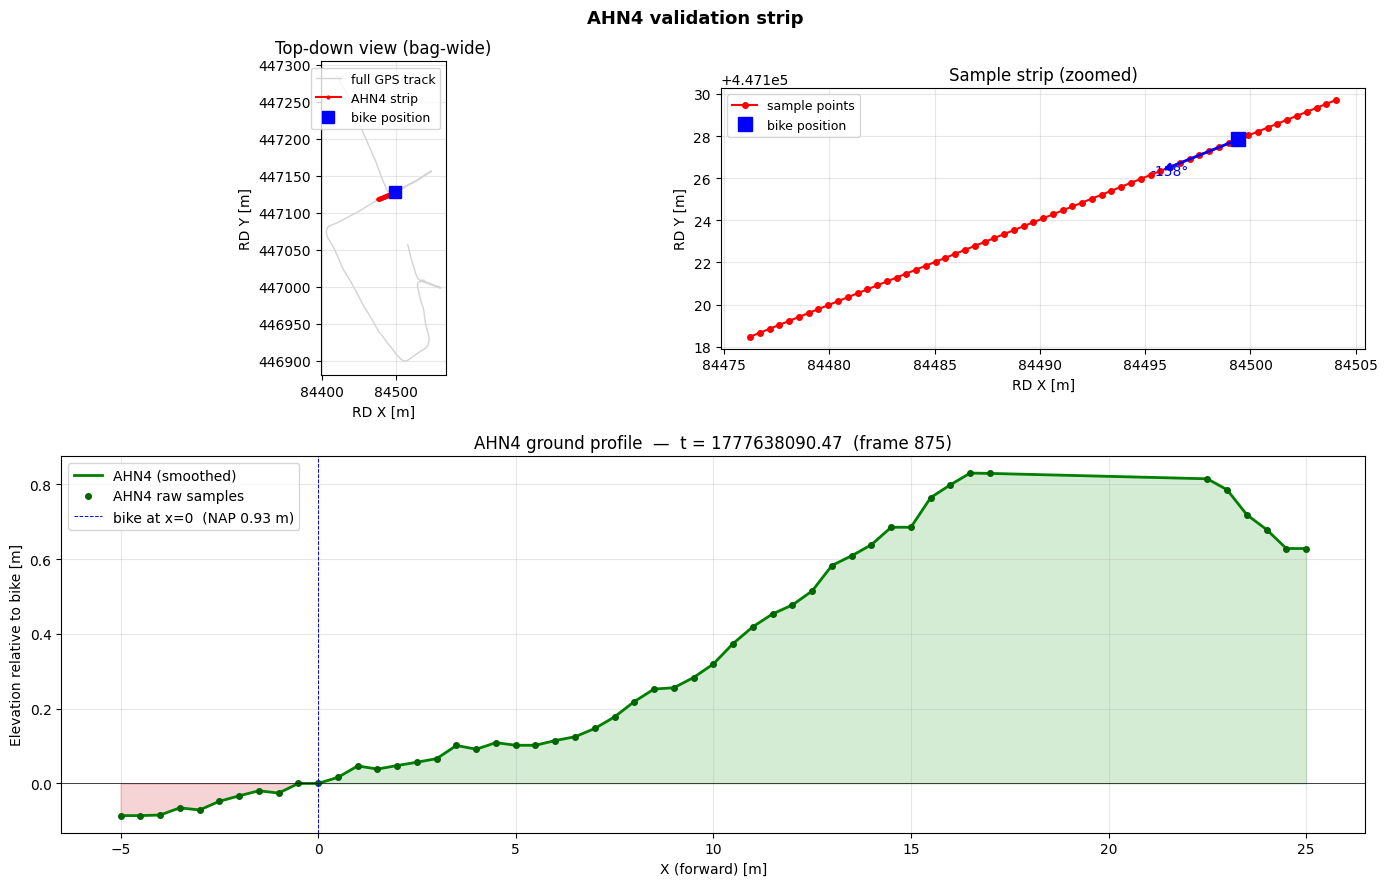

In [9]:
fig = plt.figure(figsize=(14, 9))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.2])

# --- top-left: full GPS track + strip ---
ax_map = fig.add_subplot(gs[0, 0])
ax_map.plot(rd_xs, rd_ys, "-", color="lightgray", lw=1, label="full GPS track")
ax_map.plot(sample_xs_rd, sample_ys_rd, "o-", color="red", ms=2,
            label="AHN4 strip")
ax_map.plot(ref_rd_x, ref_rd_y, "s", color="blue", ms=8, label="bike position")
ax_map.set_title(f"Top-down view (bag-wide)")
ax_map.set_xlabel("RD X [m]")
ax_map.set_ylabel("RD Y [m]")
ax_map.set_aspect("equal", adjustable="box")
ax_map.legend(loc="best", fontsize=9)
ax_map.grid(True, alpha=0.3)

# --- top-right: zoomed view of the strip ---
ax_zoom = fig.add_subplot(gs[0, 1])
ax_zoom.plot(sample_xs_rd, sample_ys_rd, "o-", color="red", ms=4,
             label="sample points")
ax_zoom.plot(ref_rd_x, ref_rd_y, "s", color="blue", ms=10,
             label="bike position")
ax_zoom.annotate("", xy=(ref_rd_x + 4*heading_x, ref_rd_y + 4*heading_y),
                 xytext=(ref_rd_x, ref_rd_y),
                 arrowprops=dict(arrowstyle="->", color="blue", lw=2))
ax_zoom.text(ref_rd_x + 4.5*heading_x, ref_rd_y + 4.5*heading_y,
             f"{heading_deg:.0f}°", color="blue")
ax_zoom.set_title("Sample strip (zoomed)")
ax_zoom.set_xlabel("RD X [m]")
ax_zoom.set_ylabel("RD Y [m]")
ax_zoom.set_aspect("equal", adjustable="box")
ax_zoom.legend(loc="best", fontsize=9)
ax_zoom.grid(True, alpha=0.3)

# --- bottom: AHN4 elevation profile (relative to bike) ---
ax_p = fig.add_subplot(gs[1, :])
ax_p.fill_between(x_samples, z_relative, 0, where=z_relative >= 0,
                  color="tab:green", alpha=0.2, label="_nolegend_")
ax_p.fill_between(x_samples, z_relative, 0, where=z_relative < 0,
                  color="tab:red",   alpha=0.2, label="_nolegend_")
ax_p.plot(x_samples, z_relative, "g-", lw=2, label="AHN4 (smoothed)")
ax_p.plot(x_samples[valid], (z_samples - ref_z_nap)[valid], "o",
          color="darkgreen", ms=4, label="AHN4 raw samples")
ax_p.axvline(0, color="blue", lw=0.7, ls="--",
             label=f"bike at x=0  (NAP {ref_z_nap:.2f} m)")
ax_p.axhline(0, color="black", lw=0.5)
ax_p.set_title(f"AHN4 ground profile  —  t = {ref_t:.2f}  "
               f"(frame {ref_idx})")
ax_p.set_xlabel("X (forward) [m]")
ax_p.set_ylabel("Elevation relative to bike [m]")
ax_p.legend(loc="best")
ax_p.grid(True, alpha=0.3)

plt.suptitle("AHN4 validation strip", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Compare with the v7 LiDAR profile

Run the v7 notebook on the LiDAR frame at the **same `TIME`** (or matching
`FRAME_INDEX` after time-syncing the bag). Once you have `profile_v7` in scope,
the cell below overlays both profiles on the same axes and prints simple
RMSE figures.

Both profiles are in the bike's local frame (z = 0 at the bike), so they're
directly overlayable. Differences in shape (slope and curvature) are the
meaningful comparison — absolute height is normalised away by construction.


In [10]:
# ============================================================
# Run this cell AFTER you have produced `profile_v7` from the
# v7 notebook on the same frame.
# ============================================================

try:
    profile_v7  # noqa
except NameError:
    print("`profile_v7` is not in scope — run the v7 notebook first, then "
          "either run this cell in the same kernel or paste profile_v7 in.")
else:
    # === align v7 to the same z=0 reference at x=0 ===
    ix0  = int(np.argmin(np.abs(profile_v7["x"])))
    v7_z = profile_v7["z"] - profile_v7["z"][ix0]

    fig, ax = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

    ax[0].plot(profile_ahn4["x"], profile_ahn4["z"],
               color="tab:green",  lw=2, label="AHN4 (truth)")
    ax[0].plot(profile_v7["x"],   v7_z,
               color="tab:blue",   lw=2, label="v7 LiDAR")
    ax[0].set_ylabel("Height z [m]")
    ax[0].set_title("v7 vs AHN4 — forward profile")
    ax[0].grid(True, alpha=0.3); ax[0].legend()

    ax[1].plot(profile_ahn4["x"], profile_ahn4["slope_deg"],
               color="tab:green", lw=2, label="AHN4")
    ax[1].plot(profile_v7["x"],   profile_v7["slope_deg"],
               color="tab:blue",  lw=2, label="v7")
    ax[1].axhline(0, color="k", lw=0.5)
    ax[1].set_ylabel("Slope [deg]")
    ax[1].grid(True, alpha=0.3); ax[1].legend()

    ax[2].plot(profile_ahn4["x"], profile_ahn4["kappa"],
               color="tab:green", lw=2, label="AHN4")
    ax[2].plot(profile_v7["x"],   profile_v7["kappa"],
               color="tab:blue",  lw=2, label="v7")
    ax[2].axhline(0, color="k", lw=0.5)
    ax[2].set_ylabel(r"Curvature $\kappa$ [1/m]")
    ax[2].set_xlabel("X (forward) [m]")
    ax[2].grid(True, alpha=0.3); ax[2].legend()

    plt.tight_layout()
    plt.show()

    # === quantitative validation (assumes shared x grid) ===
    if np.allclose(profile_ahn4["x"], profile_v7["x"]):
        err_z      = v7_z - profile_ahn4["z"]
        err_slope  = profile_v7["slope_deg"] - profile_ahn4["slope_deg"]
        err_kappa  = profile_v7["kappa"]     - profile_ahn4["kappa"]

        print(f"  Height RMSE : {np.sqrt(np.nanmean(err_z**2)):.3f} m")
        print(f"  Slope  RMSE : {np.sqrt(np.nanmean(err_slope**2)):.2f} deg")
        print(f"  κ      RMSE : {np.sqrt(np.nanmean(err_kappa**2)):.4f} 1/m")
    else:
        print("  x grids differ between AHN4 and v7 — interpolate before "
              "computing RMSE.")


`profile_v7` is not in scope — run the v7 notebook first, then either run this cell in the same kernel or paste profile_v7 in.
